In [15]:
# Enable autoreload so edits to data_prep.py are picked up automatically
%reload_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import os 
# Add the parent folder (youtube-analytics/) to Python path
sys.path.append(str(Path.cwd().parent))



# Now you can import data_prep
from data_prep import load_country

# Load US and Japan data
df_us = load_country('US')
df_jp = load_country('JP', encoding='latin-1')

# Combine both datasets
import pandas as pd
df = pd.concat([df_us, df_jp], ignore_index=True)

In [16]:
# Converts the publish_time column from a string to a datetime object
df['publish_time'] = pd.to_datetime(df['publish_time'])

# Converts the trending_date column from a string to a datetime object
df['trending_date'] = pd.to_datetime(df['trending_date'], format='%y.%d.%m')

In [24]:
df.groupby('country').size()

# Columns
df.columns

df.head()


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,...,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,category,engagement_rate,publish_hour,publish_day,country
0,ooyjaVdt-jA,2018-06-14,Official Call of Duty®: Black Ops 4 — Multipla...,Call of Duty,20,2018-05-17 17:09:38+00:00,"call of duty|""cod""|""activision""|""Black Ops 4""",10306119,357079,212976,...,https://i.ytimg.com/vi/ooyjaVdt-jA/default.jpg,False,False,False,Call of Duty: Black Ops 4 Multiplayer raises t...,Gaming,0.048697,17,3,US
1,Nd3zqXro_P0,2018-06-14,Why 350°F is the magic number for baking,Vox,25,2018-06-07 12:00:02+00:00,"baking|""maillard reaction""|""s pen""|""Vox.com""|""...",799411,16092,652,...,https://i.ytimg.com/vi/Nd3zqXro_P0/default.jpg,False,False,False,Turns out there’s a lot of chemistry in cookin...,News & Politics,0.022070,12,3,US
2,jWkOwC7vMb4,2018-06-14,“Bonding” with Grandma,itsAlexClark,1,2018-06-06 21:40:34+00:00,"its alex clark|""itsalexclark""|""alex clark""|""it...",1004181,48129,889,...,https://i.ytimg.com/vi/jWkOwC7vMb4/default.jpg,False,False,False,"You know my family, now you need to meet my gr...",Film & Animation,0.053389,21,2,US
3,T9UHD30MSGk,2018-06-14,Knife Expert Guesses Cheap vs. Expensive Knive...,Epicurious,26,2018-06-06 18:54:38+00:00,"best knife|""boning knife""|""cheap""|""cheap vs ex...",903651,11427,2305,...,https://i.ytimg.com/vi/T9UHD30MSGk/default.jpg,False,False,False,Epicurious challenges knife expert Geoff Feder...,Howto & Style,0.015416,18,2,US
4,NB3gWkhLkxM,2018-06-14,The Internet - Come Over (Official Video),TheInternetVEVO,10,2018-06-06 14:00:02+00:00,"Columbia|""Come Over""|""R&B/Soul""|""The Internet""",1615678,92403,1856,...,https://i.ytimg.com/vi/NB3gWkhLkxM/default.jpg,False,False,False,The Internet's Come Over is taken from the new...,Music,0.060021,14,2,US


In [25]:
print(df.shape)

(19263, 21)


In [26]:
df.describe()

,trending_date,category_id,views,likes,dislikes,comment_count,engagement_rate,publish_hour,publish_day
count,19263,19263.000000,1.926300e+04,1.926300e+04,1.926300e+04,1.926300e+04,19263.000000,19263.000000,19263.000000
mean,2018-03-21 11:38:39.451798,19.956289,7.981275e+05,2.286935e+04,1.208933e+03,2.767825e+03,0.026077,11.630483,2.913461
min,2017-11-14 00:00:00,1.000000,5.590000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
25%,2018-02-17 00:00:00,17.000000,2.163400e+04,1.790000e+02,1.200000e+01,3.000000e+01,0.007349,8.000000,1.000000
50%,2018-03-25 00:00:00,23.000000,9.421000e+04,1.222000e+03,7.500000e+01,2.270000e+02,0.017539,12.000000,3.000000
75%,2018-05-04 00:00:00,24.000000,4.104965e+05,7.750000e+03,3.910000e+02,1.081000e+03,0.035497,16.000000,5.000000
max,2018-06-14 00:00:00,43.000000,2.252119e+08,5.613827e+06,1.674420e+06,1.361580e+06,0.405253,23.000000,6.000000
std,NaN,6.877343,4.225058e+06,1.254713e+05,1.849334e+04,2.150821e+04,0.027867,5.981167,1.977219


In [20]:
# Extract time-based features
df['publish_hour'] = df['publish_time'].dt.hour
df['publish_day'] = df['publish_time'].dt.dayofweek  # 0=Monday


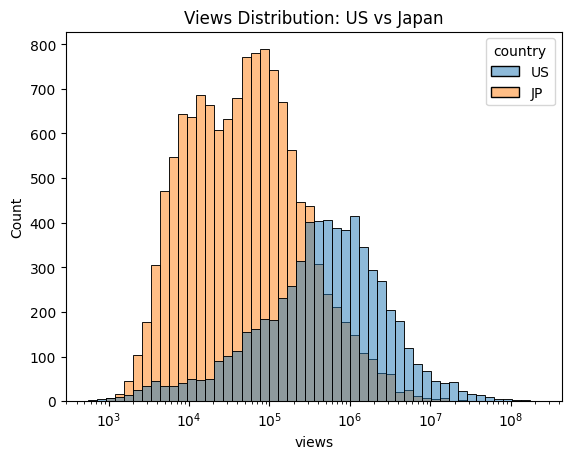

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=df, x='views', hue='country', log_scale=True, bins=50)
plt.title("Views Distribution: US vs Japan")
plt.show()

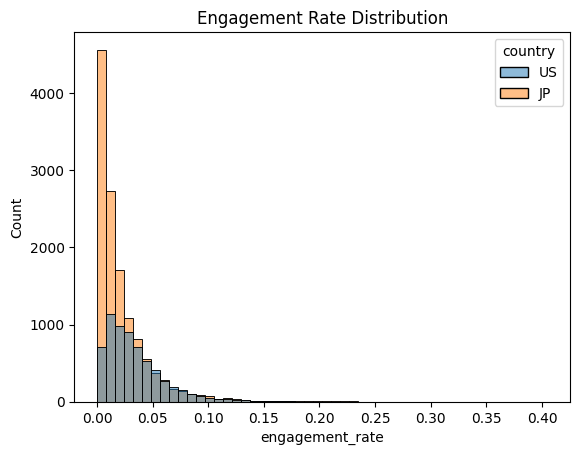

In [34]:
sns.histplot(data=df, x='engagement_rate', hue='country', bins=50)
plt.title("Engagement Rate Distribution")
plt.show()

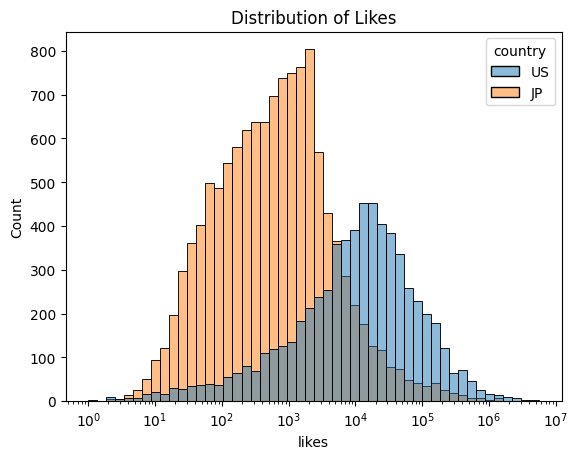

In [35]:
sns.histplot(data=df, x='likes', hue='country', bins=50, log_scale=True)
plt.title("Distribution of Likes")
plt.show()


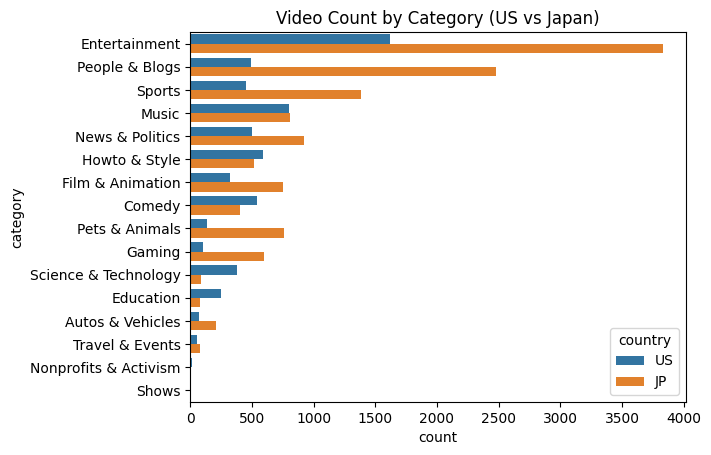

In [36]:
import sys
import os
sys.path.append(os.path.abspath('..'))  # go up one level to project root

from data_prep import get_cat_map, load_and_clean

df['category'].value_counts()
sns.countplot(
    data=df,
    y='category',
    hue='country',
    order=df['category'].value_counts().index
)
plt.title("Video Count by Category (US vs Japan)")
plt.show()

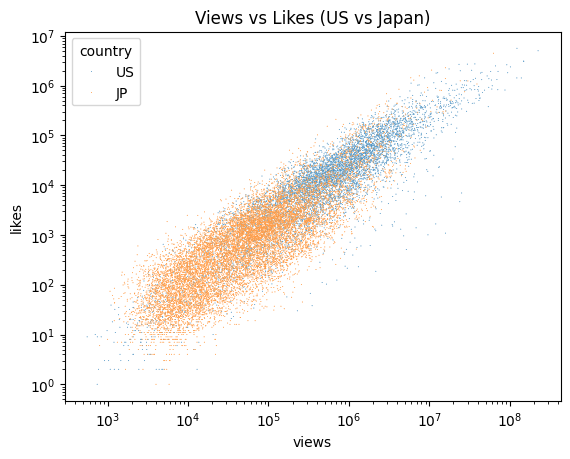

In [41]:
sns.scatterplot(data=df, x='views', y='likes', hue='country', s=0.5)
plt.xscale('log')
plt.yscale('log')
plt.title("Views vs Likes (US vs Japan)")
plt.show()

In [66]:
df.groupby('category')['views'].mean().sort_values(ascending=False)

category
Music                    6.201003e+06
Film & Animation         3.106250e+06
Nonprofits & Activism    2.963884e+06
Gaming                   2.620831e+06
Entertainment            2.067883e+06
Sports                   2.025969e+06
People & Blogs           1.531835e+06
Comedy                   1.480308e+06
Science & Technology     1.452627e+06
Autos & Vehicles         1.355965e+06
Howto & Style            9.837301e+05
Shows                    9.035273e+05
Travel & Events          8.546196e+05
Pets & Animals           8.311435e+05
Education                7.129408e+05
News & Politics          5.925877e+05
Name: views, dtype: float64

In [43]:
df.groupby(['country', 'publish_hour'])['engagement_rate'].mean()

# For each publish_hour (0-23), the engagement rate (likes + comments / views)
# is shown. For exmample, videos posted at hour 13 (1:00 pm) have an engagement
# rate of 3.32%. 

country  publish_hour
JP       0               0.020674
         1               0.023070
         2               0.017758
         3               0.022469
         4               0.016825
         5               0.013784
         6               0.016479
         7               0.018115
         8               0.022563
         9               0.025012
         10              0.025673
         11              0.026217
         12              0.024783
         13              0.022588
         14              0.019851
         15              0.025541
         16              0.019520
         17              0.020581
         18              0.019258
         19              0.021552
         20              0.016255
         21              0.022132
         22              0.019704
         23              0.021436
US       0               0.033608
         1               0.033800
         2               0.027404
         3               0.030373
         4               0

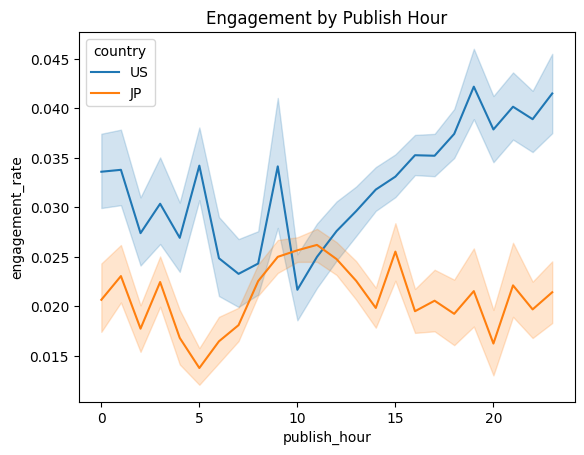

In [44]:
sns.lineplot(
    data=df,
    x='publish_hour',
    y='engagement_rate',
    hue='country'
)
plt.title("Engagement by Publish Hour")
plt.show()

In [72]:
# Remove duplicates by video_id, keeping the row with the highest views
df_unique = df.sort_values('views', ascending=False).drop_duplicates(subset='video_id', keep='first')

# Top 10 most viewed unique videos
top10_videos = df_unique.head(10)
top10_videos[['video_id', 'title', 'views', 'engagement_rate', 'category']]


,video_id,title,views,engagement_rate,category
38547,VYOjWnS4cMY,Childish Gambino - This Is America (Official V...,225211923,0.024602,Music
6181,FlsCjmMhFmw,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,149376127,0.026137,Entertainment
34708,ffxKSjUwKdU,Ariana Grande - No Tears Left To Cry,148689896,0.022436,Music
34888,zEf423kYfqk,"Becky G, Natti Natasha - Sin Pijama (Official ...",139334502,0.010833,Music
38273,7C2z4GqqS5E,BTS (방탄소년단) 'FAKE LOVE' Official MV,123010920,0.055625,Music
34747,M4ZoCHID9GI,The Weeknd - Call Out My Name (Official Video),122544931,0.012100,Music
2587,TyHvyGVs42U,"Luis Fonsi, Demi Lovato - Échame La Culpa",102012605,0.024613,Music
40869,xTlNMmZKwpA,"Cardi B, Bad Bunny & J Balvin - I Like It [Off...",94254507,0.020347,Music
4997,6ZfuNTqbHE8,Marvel Studios' Avengers: Infinity War Officia...,91933007,0.032373,Entertainment
25947,-BQJo3vK8O8,Maluma - El Préstamo (Official Video),87264467,0.009756,Music
